In [3]:
%matplotlib inline
from lib.Vector import CoordinateVector as Vector
from lib.Line import Line
from lib.Matrix import Matrix
from lib.Plotter import Plotter
from lib.Game import Game
import matplotlib.pyplot as plt
from math import *
from random import randint, uniform

(False, True, True, True)


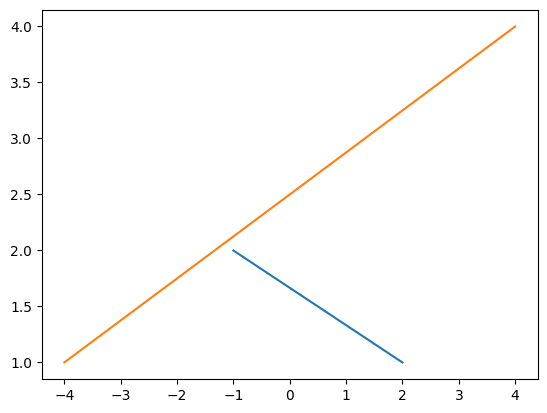

In [4]:
drawer = Plotter(plt)

def segments_check(s1: Line, s2: Line):
    p = s1.intersection(s2)
    if p is None:
        return False
    dist1 = s1.a.distance(s1.b)
    dist2 = s2.a.distance(s2.b)
    checks = tuple(
            v.distance(p) <= dist1 for v in s1.points
        ) + tuple(
            v.distance(p) <= dist2 for v in s2.points
        )
    if len(tuple(c for c in checks if not c)) == 1:
        print(checks)
        return True
    return False
    
for i in range(10):
    l1 = Line.random(-3, 3)
    l2 = Line.random(-5, 5)
    
    if segments_check(l1, l2):
        drawer.segment(*l1.points)
        drawer.segment(*l2.points)
        break

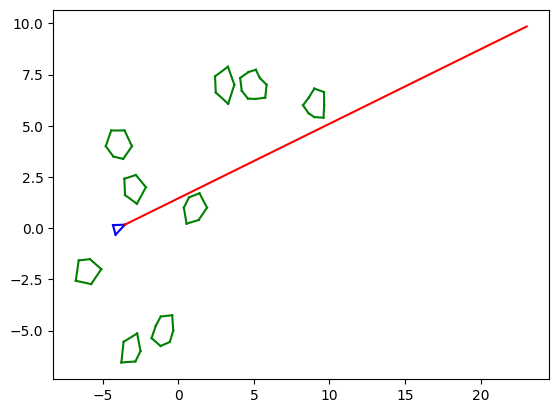

In [5]:
g = Game()
#g.render()
g.handle("move<").handle("move<").handle("move<").handle("move<")
g.handle("turn<").handle("turn<")
g.handle("shoot")
g.render()

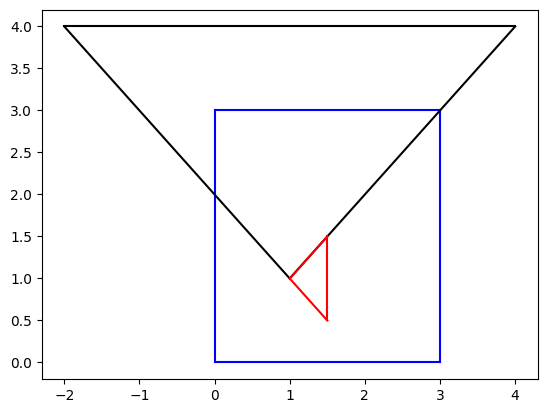

True

In [6]:
from lib.Polygon import PolygonModel as Polygon
p1 = Polygon(
    Vector(0, 0),
    Vector(0, 3),
    Vector(3, 3),
    Vector(3,0)
)

p2 = Polygon(
    Vector(1,1),
    Vector(4,4),
    Vector(-2, 4)
)

p3 = Polygon(
    Vector(1,1),
    Vector(1.5,1.5),
    Vector(1.5, 0.5)
)

drawer = Plotter(plt)
drawer.polygon(p1.points, color="blue")
drawer.polygon(p2.points, color="black")
drawer.polygon(p3.points, color="red")
drawer.show()

p1.does_collide(p2)
# p1.does_collide(p3)

In [7]:
import numpy as np

def plane_standard_form(A: Vector, B: Vector, C: Vector):
    AB = A - B
    AC = A - C
    a,b,c = np.cross(np.array(AB.coords), np.array(AC.coords))
    d = a*A.x + b*A.y + c*A.z
    return Vector(a,b,c,d)

def draw_plane(a,b,c,d, ax):
    steps = 20
    xspace = np.linspace(-10, 10, steps)
    xx, yy = np.meshgrid(xspace, xspace)
    if c != 0:
        zz = (d - a*xx - b*yy) / c
    elif b != 0:
        zz = yy
        yy = (d - a*xx - c*zz) / b
    elif a != 0:
        zz = xx
        xx = (d - b*yy - c*zz) / a
        
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.plot_surface(xx, yy, zz, alpha=0.3, color=(0, 0, 1))




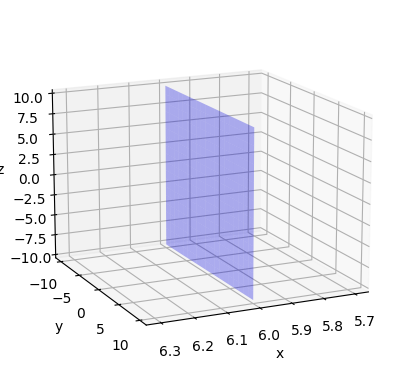

In [8]:
ax = plt.subplot(projection='3d')
draw_plane(1,0,0,6,ax)
ax.view_init(elev=15, azim=65)
plt.show()

In [6]:
A = Vector(2,2,0)
B = Vector(1, 4, 0)
C = Vector(0, -3, 0)
plane_standard_form(A, B, C)

Vec4(0, 0, 9, 0)

In [4]:
A = Vector(1,1,1)
B = Vector(2,2,2)
C = Vector(3,3,3)
plane_standard_form(A, B, C)

Vec4(0, 0, 0, 0)

In [2]:
import numpy as np
x = np.array((1,2,3))
y = np.array((2,1,0))


xx, yy = np.meshgrid(x,y)

zz = 1 * yy
xx, yy, zz

(array([[1, 2, 3],
        [1, 2, 3],
        [1, 2, 3]]),
 array([[2, 2, 2],
        [1, 1, 1],
        [0, 0, 0]]),
 array([[2, 2, 2],
        [1, 1, 1],
        [0, 0, 0]]))

In [9]:
import numpy as np
xx = np.array((
    (0,0,0),
    (1,1,1),
    (2,2,2)
))
yy = np.array((
    (0,1,2),
    (0,1,2),
    (0,1,2)
))
zz = np.array((
    (3,2,1),
    (2,1,0),
    (1,0,-1)
))


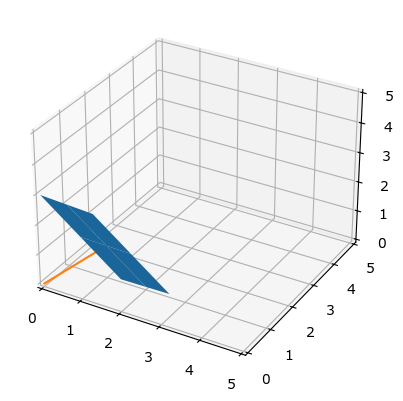

In [13]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(xx,yy,zz)
ax.plot((0,1),(0,1),(0,1))
ax.set_zlim(0, 5)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.show()

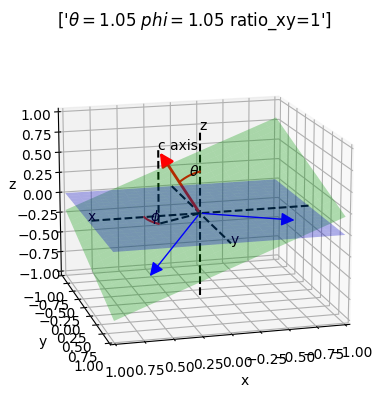

In [9]:
# To show the incident angle in 3D axis
# Date: 2019 08 03
# Authour: Zhaohua Tian

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

theta = np.pi / 3
phi = np.pi / 3


class Arrow3D(FancyArrowPatch):

    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))

        return np.min(zs)


# Prepare the coordinate matrix
num_arrow = 3
coor0 = np.zeros((1, 3))
row = np.ones((num_arrow, 1))
coor = np.matmul(row, coor0)
x = np.cos(theta) * np.sin(phi)
y = np.cos(theta) * np.cos(phi)
z = np.sin(theta)

ar_1 = np.array([x, y, z])
nar_1 = ar_1 / np.sqrt(ar_1[0] ** 2 + ar_1[1] ** 2 + ar_1[2] ** 2)

ratio_xy = 1
ar_2 = np.array([1, ratio_xy, -y / z * ratio_xy - x / z])
nar_2 = ar_2 / np.sqrt(ar_2[0] ** 2 + ar_2[1] ** 2 + ar_2[2] ** 2)

nar_3 = np.cross(nar_1, nar_2)

# To plot the projection of nar_1
num = 20
x_mat = np.linspace(-1, 1, num)
z_mat = np.linspace(0, 1, num)
line_1_xy = np.array([(z_mat)*x, (z_mat)*y, (z_mat)*0])
line_1_z = np.array([np.ones(num)*x, np.ones(num)*y, (z_mat)*z])

# To  plot the x,y,z coordinate
line_x = np.array([x_mat, x_mat*0, x_mat*0])
line_y = np.array([x_mat*0, x_mat, x_mat*0])
line_z = np.array([x_mat*0, x_mat*0, x_mat])

# To plot the xy plane
xx, yy = np.meshgrid(x_mat, x_mat)
zz_xy = np.zeros((num, num))
# to plot the orthogonal plane
zz_or = (-x*xx-y*yy)/z
# To plot the \theta \phi
theta_x = z_mat*x*0.5
theta_y = z_mat*y*0.5
theta_z = np.sqrt(0.25-theta_x**2-theta_y**2)

phi_y = np.linspace(0, y, num)
phi_x = np.sqrt(x**2+y**2-phi_y**2)
phi_z = np.zeros(num)
# Plot part
# Plot the arrow
fig = plt.figure()
ax = fig.add_subplot(projection='3d')


# Three arrows
a1 = Arrow3D([0, nar_1[0]], [0, nar_1[1]], [0, nar_1[2]], mutation_scale=20,
             lw=2, arrowstyle="-|>", color="r")
ax.add_artist(a1)

a2 = Arrow3D([0, nar_2[0]], [0, nar_2[1]], [0, nar_2[2]], mutation_scale=20,
             lw=1, arrowstyle="-|>", color="b")
ax.add_artist(a2)

a3 = Arrow3D([0, nar_3[0]], [0, nar_3[1]], [0, nar_3[2]], mutation_scale=20,
             lw=1, arrowstyle="-|>", color="b")
ax.add_artist(a3)
# The projection
a4 = ax.plot(line_1_xy[0, :], line_1_xy[1, :], line_1_xy[2, :], 'k--')
a5 = ax.plot(line_1_z[0, :], line_1_z[1, :], line_1_z[2, :], 'k--')

# The x,y,z coordinate
ax_x = ax.plot(line_x[0, :], line_x[1, :], line_x[2, :], 'k--')
ax_y = ax.plot(line_y[0, :], line_y[1, :], line_y[2, :], 'k--')
ax_z = ax.plot(line_z[0, :], line_z[1, :], line_z[2, :], 'k--')
# The xy plane
surf_xy = ax.plot_surface(xx, yy, zz_xy, alpha=0.3, color=(0, 0, 1))
# The orthogonal plane
surf_or = ax.plot_surface(xx, yy, zz_or, alpha=0.3, color=(0, 1, 0))
# The theta angle
theta_angle = ax.plot(theta_x, theta_y, theta_z, 'r-')
# The phi angle
phi_angle = ax.plot(phi_x, phi_y, phi_z, 'r-')

ax.set_xlim((-1, 1))
ax.set_ylim((-1, 1))
ax.set_zlim(-1, 1)
ax.text(0, 0, 1, 'z')
ax.text(1, 0, 0, 'x')
ax.text(0, 1, 0, 'y')
ax.text(x, y, z, 'c axis')
ax.text(theta_x[10], theta_y[10], theta_z[10], '$\\theta$')
ax.text(phi_x[10], phi_y[10], phi_z[10], '$\\phi$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title(['$\theta = $' + str(round(theta, 2))+' '+'$ phi = $' +
              str(round(phi, 2))+' '+'ratio_xy=' + str(round(ratio_xy, 2))])
#
ax.view_init(elev=15, azim=75)
plt.show()

In [15]:

import numpy as np
def draw_plane(a,b,c,d, ax, alpha=0.3, color=None):
    steps = 20
    xspace = np.linspace(-10, 10, steps)
    xx, yy = np.meshgrid(xspace, xspace)
    if c != 0:
        zz = (d - a*xx - b*yy) / c
    elif b != 0:
        zz = yy
        yy = (d - a*xx - c*zz) / b
    elif a != 0:
        zz = xx
        xx = (d - b*yy - c*zz) / a
        
    ax.plot_surface(xx, yy, zz, alpha=alpha, color=color)

## Exercise 7.22 
Sketch tree planes, none of which are parallel and do not have a single point of intersection

interactive(children=(IntSlider(value=1, description='a', max=3, min=-1), IntSlider(value=1, description='b', …

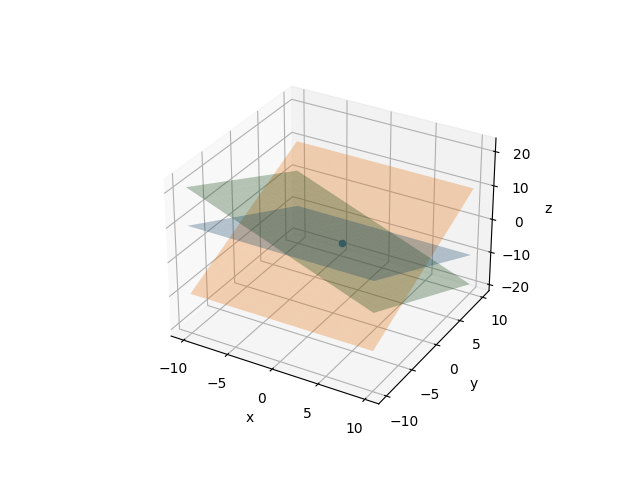

In [14]:

%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from lib.Plotter import Plotter
from lib.Vector import CoordinateVector as Vector
drawer = Plotter(plt, subplot_kw={"projection": "3d"})

@interact(a=1, b=1, c=1, d=1)
def plot_planes(a, b, c, d):
    drawer.ax.clear()
    drawer.label_axises()
    p1 = (0,1,1,0)
    p2 = (0, -1, 1, 0)
    p3 = (a, b, c, d)
    drawer.plane(*p1)
    drawer.plane(*p2)
    drawer.plane(*p3)

    m = np.array(
        (
            p1[:3], p2[:3],
            p3[:3]
        )
    )

    o = np.array([p1[3], p2[3],
                  p3[3]
                  ])

    try:
        solution = np.linalg.solve(m, o)
        drawer.point(Vector(*solution))
        print(f"Solution: {solution}")
    except Exception as e:
    # Catch all exceptions and print the error message along with traceback
        print(f"No solution: {e}")
        pass


In [18]:
m = np.array([
    [0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 0, 0]
]
)
o = np.array(
    [3, 1, -1, 0, -2]
)
np.linalg.solve(m, o)

array([ 0.,  1., -3., -1.,  3.])

## Exercise 7.26 Inverse matrix



In [45]:
m = np.array([
    [1, 1, -1],
    [0, 2, -1],
    [1, 0, 1]
])

v = np.array(
    [-1, 3, 2]
)

inv_m = np.linalg.inv(m)

inv_result = np.matmul(inv_m, v)
solve_result = np.linalg.solve(m, v)

inv_result, solve_result, inv_result[1], solve_result[1]


(array([-1.,  3.,  3.]), array([-1.,  3.,  3.]), 2.9999999999999996, 3.0)

In [43]:
m = np.array([
    [0, 1, 1],
    [0, -1, 1],
    [0, 0, 1]
])

v = np.array([0, 0, 0])

# np.linalg.solve(m, v)
inv_m = np.linalg.inv(m)



LinAlgError: Singular matrix